In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score)
from sklearn.preprocessing import LabelEncoder

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

In [7]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Rescaling
)

In [8]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [9]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATASET_PATH = '/mnt/d/datasets/fruits-vegetables-freshness-detection/dataset'
SEED = 42

In [10]:
full_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

class_names = full_ds.class_names

print(class_names)

Found 11986 files belonging to 2 classes.
['fresh', 'rotten']


In [11]:
total_batches = tf.data.experimental.cardinality(full_ds).numpy()

train_size = int(0.70 * total_batches)
val_size = int(0.15 * total_batches)

test_size = total_batches - train_size - val_size

print("Total batches:", total_batches)
print("Train batches:", train_size)
print("Validation batches:", val_size)
print("Test batches:", test_size)

Total batches: 375
Train batches: 262
Validation batches: 56
Test batches: 57


In [12]:
train_ds = full_ds.take(train_size)

remaining_ds = full_ds.skip(train_size)

val_ds = remaining_ds.take(val_size)

test_ds = remaining_ds.skip(val_size)

In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [14]:
model = Sequential([
    
    Input(shape=(224, 224, 3)),

    Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.0001)
    ),
    
    BatchNormalization(),
    
    MaxPooling2D((2, 2)),
    
    Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.0001)
    ),
    
    BatchNormalization(),
    
    MaxPooling2D((2, 2)),
    
    Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.0001)
    ),
    
    BatchNormalization(),
    
    MaxPooling2D((2, 2)),
    
    Conv2D(
        256,
        (3, 3),
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.0001)
    ),
    
    BatchNormalization(),

    MaxPooling2D((2, 2)),

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(0.0001)
    ),
    
    Dropout(0.5),

    Dense(
        len(class_names),
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,490 (1.62 MB)

 Trainable params: 422,530 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [15]:
model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=0.000001
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

Epoch 1/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 45s 122ms/step - accuracy: 0.7343 - loss: 0.6004 - val_accuracy: 0.8214 - val_loss: 0.4706 - learning_rate: 3.0000e-04
Epoch 2/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 29s 111ms/step - accuracy: 0.8214 - loss: 0.4531 - val_accuracy: 0.8477 - val_loss: 0.4075 - learning_rate: 3.0000e-04
Epoch 3/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 29s 111ms/step - accuracy: 0.8424 - loss: 0.4054 - val_accuracy: 0.8644 - val_loss: 0.3734 - learning_rate: 3.0000e-04
Epoch 4/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 29s 110ms/step - accuracy: 0.8597 - loss: 0.3735 - val_accuracy: 0.8571 - val_loss: 0.3724 - learning_rate: 3.0000e-04
Epoch 5/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 28s 107ms/step - accuracy: 0.8746 - loss: 0.3473 - val_accuracy: 0.8901 - val_loss: 0.3301 - learning_rate: 3.0000e-04
Epoch 6/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 29s 110ms/step - accuracy: 0.8835 - loss: 0.3312 - val_accuracy: 0.8320 - val_loss: 0.4075 - learning_rate: 3.0000e-04
Epoch 7/30
262/262 ━━━━━━━━━━━━━━━━━━━━ 30s 11

In [17]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

print("\nTesting Loss    :", test_loss)
print("Testing Accuracy:", test_accuracy)


Testing Loss    : 0.15758571028709412
Testing Accuracy: 0.9591160416603088


In [18]:
y_true = []
y_pred = []

for images, labels in test_ds:
    
    predictions = model.predict(images, verbose=0)
    
    predicted_labels = np.argmax(predictions, axis=1)
    
    y_true.extend(labels.numpy())
    
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

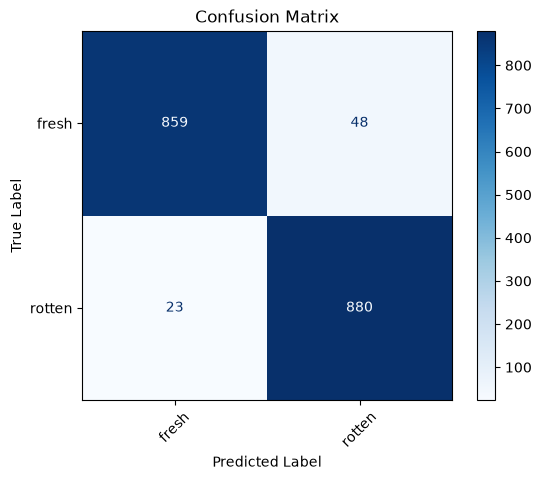

In [20]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

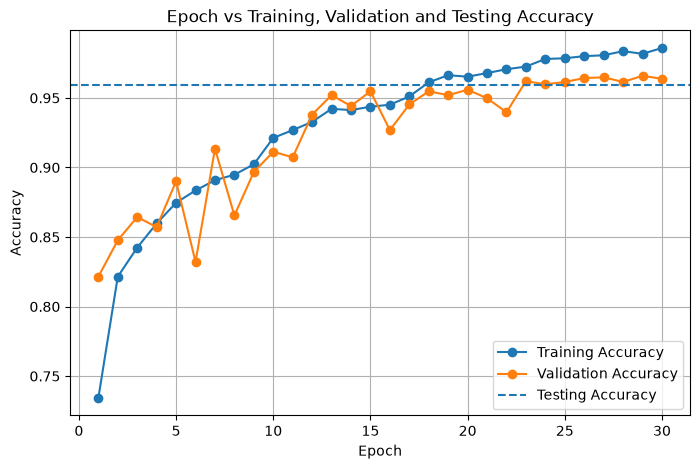

In [21]:
epochs = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.axhline(
    test_accuracy,
    linestyle="--",
    label="Testing Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Epoch vs Training, Validation and Testing Accuracy")
plt.legend()
plt.grid(True)
plt.show()

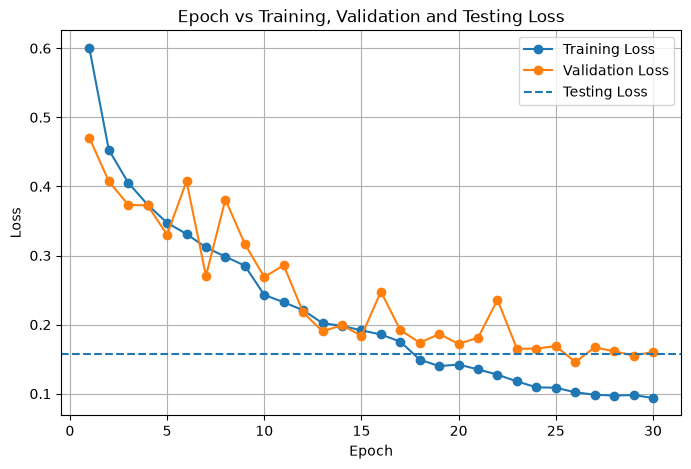

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axhline(
    test_loss,
    linestyle="--",
    label="Testing Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Training, Validation and Testing Loss")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
model.save("/mnt/d/jupyter/Freshness-Detection/freshness-detection-cnn-model.keras")

In [24]:
model.save("/mnt/d/jupyter/Freshness-Detection/freshness-detection-cnn-model.h5")